# Chapter 3: Attention Mechanism

Prior to LLM, transformer architecture's was primarily used for language translation, and translating a text word by word isn't feasible due to the differences in grammar between languages.

To address this problem, encoder-decoder RNN were commonly used for machine translation texts. However, the big limitations of encoder-decoder RNNs is that the RNN can't directly access ealier hidden states from the encoder during the decoding phase. This can lead to a loss of context, especially in complex sentences where dependencies might span long distances.

Self-attention is introduced in the transformer architecture as a technique to enhance input representations by enabling each position in the sequence to engage with relevancy, or "attend to" other positions in the same sequence.

## Simple self-attention mechanism without trainable weights

In [4]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

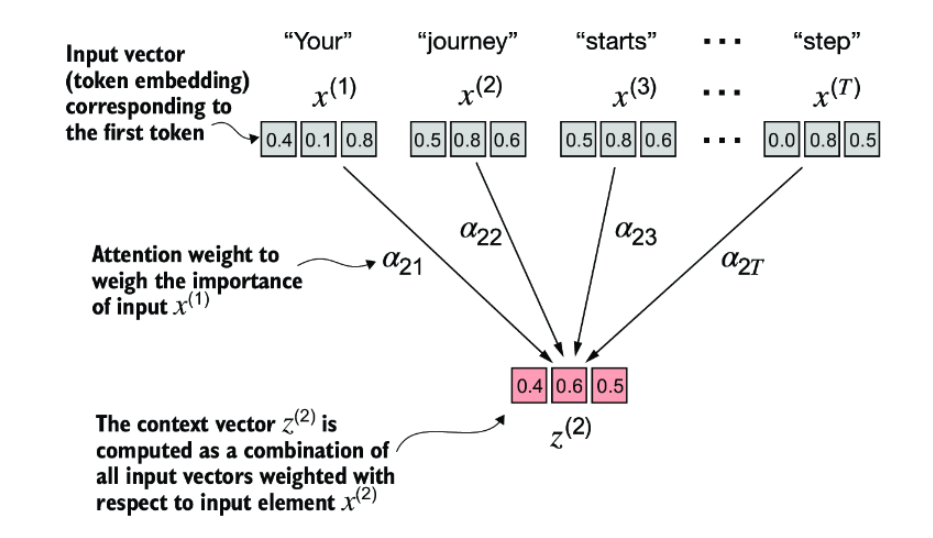

The goal of the self-attention is to compute a **context vector** for each input element that combines the relevancy from all other input elements. In this example, we should such context vector for one particular input element "journey" - x(2), and the context vector output is z(2).

The simplified mechanism is:
1. Compute **attention score**: treat the current token embedding as query and dot product with every token embedding to get similarity-based score.
2. Normalize to **attention weights**: convert scores into weights that sum to 1 (preferably with softmax).
3. **Context vector**: computed as a weighted sum over the inputs.

## Implementing self-attention with trainable weights

Our next step is to implement self-attention mechanism used in the original transformer architecture. This self-attention mechanism is also called **scaled dot-product attention**.

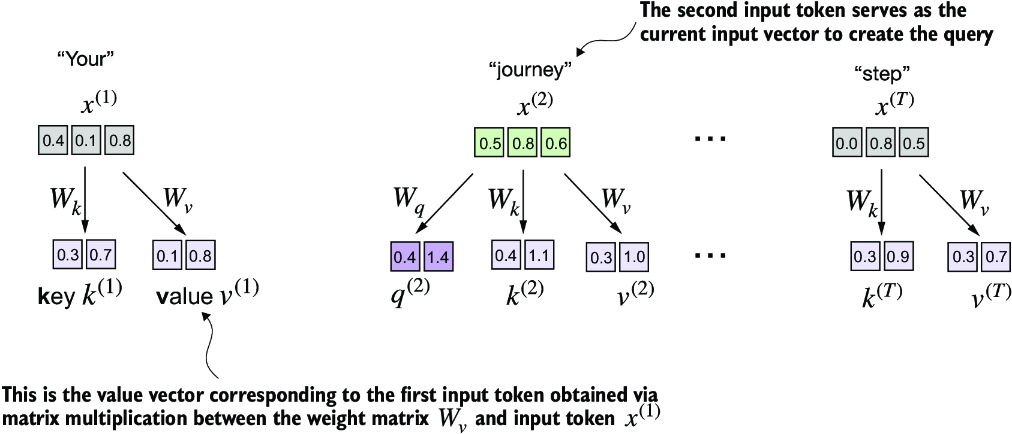

We project inputs into Q, K, V. Each token embedding x(i) is linearly projected into a query, key, and value vector using three learned **weight matrices** Wq, Wk, Wv.

In GPT models, the input and output dimensions are usually the same, but for illustration purpose, we choose different input and output. As shown in the previous graph, our input has dimension of 3, and output has dimension of 2.

In [5]:
x_2 = inputs[1] # second input element "journey"
d_in = inputs.shape[1] # the input embedding size, d = 3
d_out = 2 # the output embedding size, d = 2

In [6]:
torch.manual_seed(123)

# Initialize three weight matrices, set require_grad=False here for illustration purposes
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [11]:
# Compute the query, key, and value vectors
query_2 = x_2 @ W_query 
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)

tensor([0.4306, 1.4551])


In [13]:
# Compute all the keys and values
keys = inputs @ W_key
values = inputs @ W_value

# You can see we projected 6 input tokens from 3D into 2D embedding space
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


#### Compute attention score
We compute the unnormalized attention scores by computing the dot product between the query and each key vector. 

In [16]:
attn_scores_2 = query_2 @ keys.T # all attention score for given query
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


#### Normalize to attention weights
- We compute the attention weights (normalized attention scores that sum up to 1) using the softmax
- The only difference is that we now scale the attention scores by dividing them by the square root of the embedding dimension (i.e `d_k ** 0.5`). This is for training optimization purposes, which is also why we call it "scaled dot-product attention".

In [19]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k ** 0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


#### Compute context vector
We now compute the context vector for input query vector 2 ("journey") by multiplying each value vector with its respective attention weight and then summing them. 

In [20]:
# We use matrix multiplication to obtain the final step
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


Here is the full architecture graph 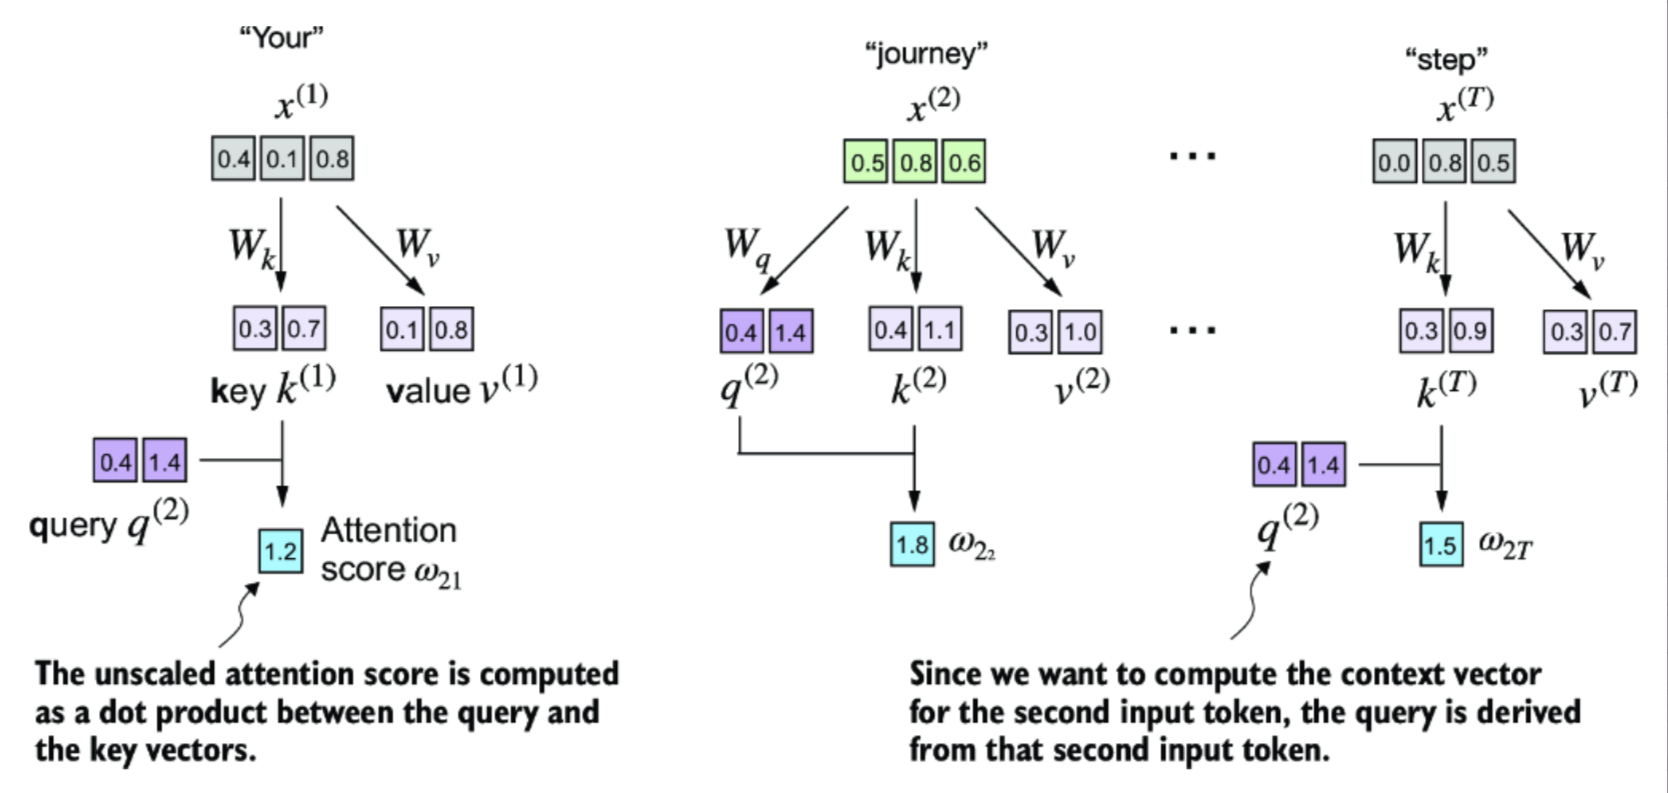

## Implementing a compact self-attention Python class

- Class derive from `nn.Module` which is a fundamental building block of PyTorch models that provides necessary functionalies for model layer creation and management.
- We can improve performance by using PyTorch's `nn.Linear` layers, which effectively performs matrix multiplication when the bias units are disabled. Also, it has an optimized weight initialization scheme.

In [22]:
import torch.nn as nn
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [24]:
# Use class as follows
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))  # These are the context vectors for each input token embeddings (6 total)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


## Hiding future words with causal attention

Causal attention, also known as masked attention, ensuring that for any given input, the LLM is unable to use future tokens while calculating the context vectors. 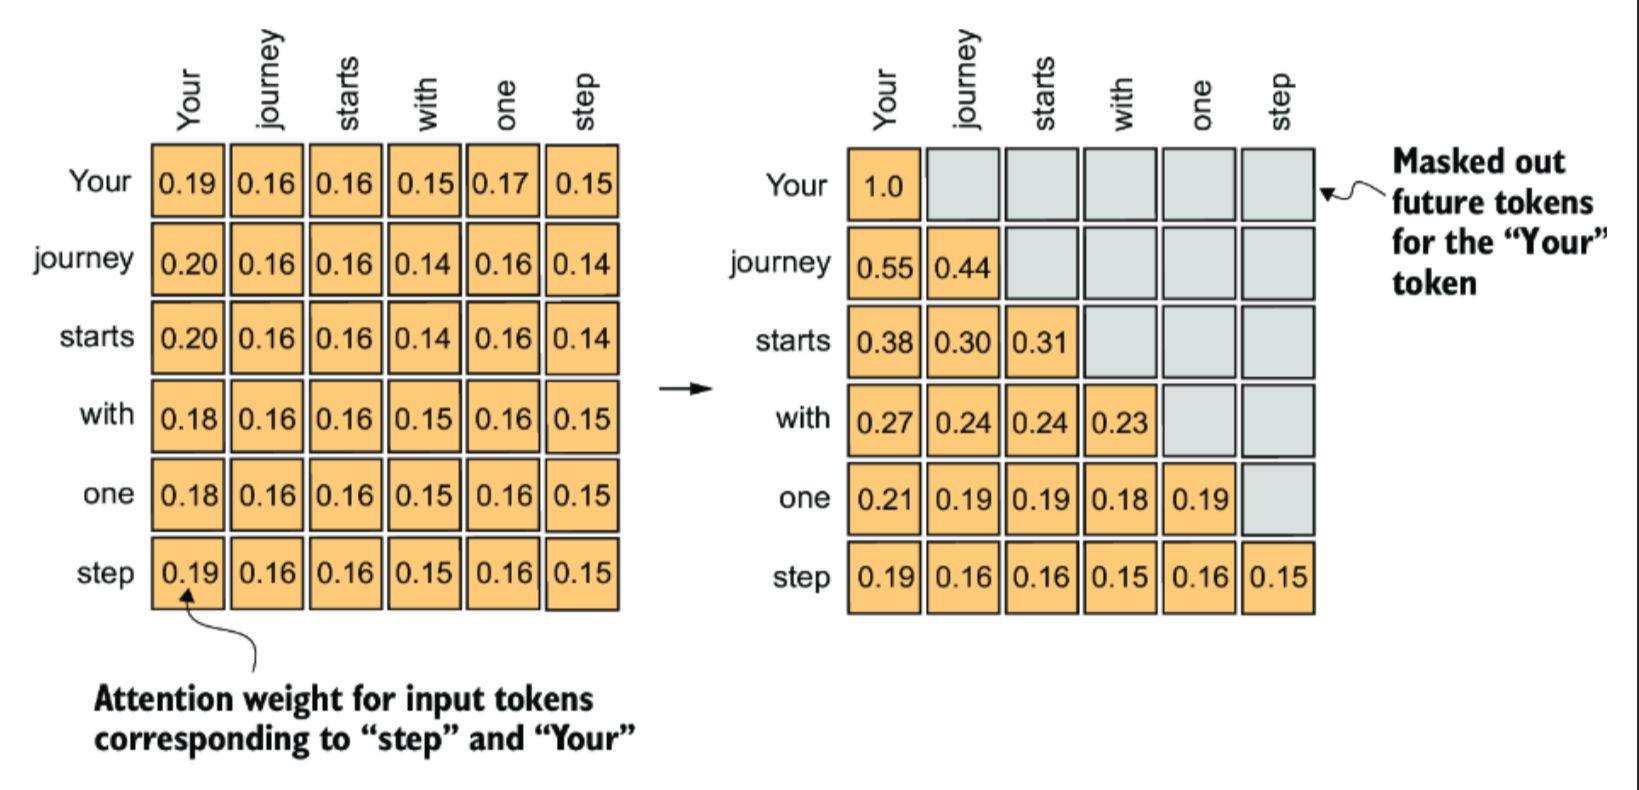

In [27]:
# First step, repeat the steps to compute attention weights
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [29]:
# Second step, use PyTorch's tril function to create a mask
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [31]:
# Multiply
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [33]:
# Third step, we need to renormalize the attention weight one more time 
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


One optimization: instead of masking after softmax, we can mask the attention score before softmax by filling future positions with `-inf` before we enter the softmax function

## Masking additional attention weights with dropout

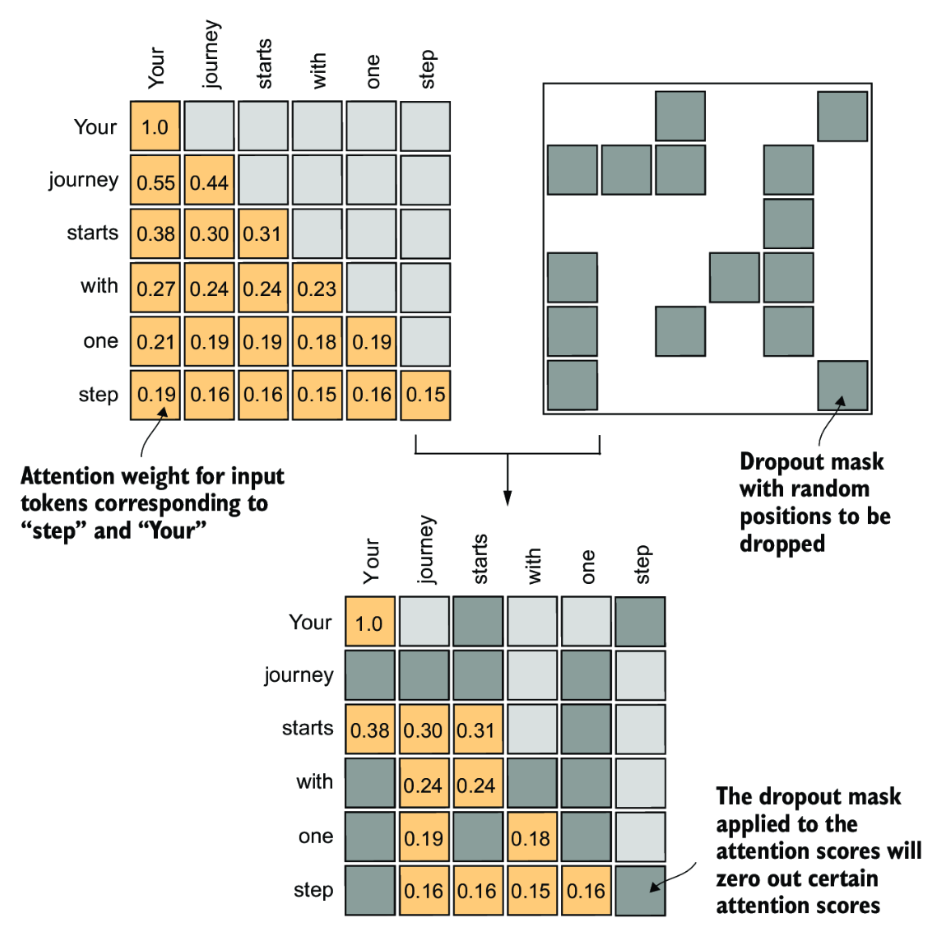

- Dropout helps prevent overfitting.
- Dropout is only used for training and disabled afterward
- It can be applied after computing the attention weights or after multiplying the attentino weights with value vectors.
- This is a technique used in GPT2, but it's less popular for LLM training nowadays.

In [35]:
# We use 50% dropout rate for illustration purposes
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


- To compensate the droped values, remaining elements are scaled up.


In [38]:
torch.manual_seed(123)
print(dropout(masked_simple_norm))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)
